# Cross-Modal Diagnostic Observability — Stage T2-E

## 论文级强基线、机制消融、适用性与 blind readiness

这一册只读回已经正式通过的 Stage T2-D，并在相同 13 个 development targets、27 条边、预算 32 上完成投稿前压力测试：

- SSME-KDE 官方算法结构对齐的自包含复现；
- Active Testing 原则的 AUC 适配；
- 主动选择、多源证据空间、未标注积分与交叉拟合消融；
- target-level 精确推断与 dermoscopy 失败专项；
- 适用性诊断、冻结证书半径、blind 资产/统计可行性账本。

**本 notebook 不修改 AMW-DDET，不读取三个 locked-blind targets。** 通过最多只授权封存 blind 预注册与资产 acquisition preflight；不会启动 Stage 12。

普通 CPU，干净 Colab 运行时，直接 `Run all`。正式设置约 20–40 分钟。


In [1]:
# @title T2-E-0. Mount Drive, verify immutable parents, and seal this audit
import hashlib, json, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit, logit, logsumexp
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    pass

LOCAL_MODE = bool(os.environ.get('DDET_LOCAL_MODE'))
DEFAULT_ROOT = Path('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability') if IN_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get('CDO_PROJECT_ROOT', str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT/'05_Code'/'Cross_Modal' if not LOCAL_MODE else Path.cwd()
CM_ROOT = PROJECT_ROOT/'06_Data_Records'/'Cross_Modal' if not LOCAL_MODE else Path(os.environ.get('DDET_LOCAL_RECORD','/tmp/AMW_DDET_T2E_Local_Record'))
RESULT_ROOT = CM_ROOT/'StageT2-E_Development_Only_Paper_Grade_Baselines_Ablations_Applicability_And_Blind_Readiness_v0.1'
P0,P1,P2,P3,P4 = [RESULT_ROOT/x for x in ['00_Protocol','01_New_Baselines_And_Ablations','02_Applicability','03_Gates_And_Blind_Readiness','04_Results']]
for path in [CODE_ROOT,P0,P1,P2,P3,P4]: path.mkdir(parents=True,exist_ok=True)

NOTEBOOK_NAME='CrossModal_StageT2-E_Development_Only_Paper_Grade_Baselines_Ablations_Applicability_And_Blind_Readiness_v0.1.ipynb'
NOTEBOOK_PATH=CODE_ROOT/NOTEBOOK_NAME
THEORY_NAME='Directed_Diagnostic_Evidence_Transport_Selective_Certification_Theory_v0.4.md'
PREREG_NAME='StageT2-E_AMW-DDET_Paper_Grade_Baseline_Ablation_Applicability_And_Blind_Readiness_Preregistration_v0.1.md'
PARENT_FINAL_SHA='9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c3775f40fedd2f3a6820a5fa'
PARENT_SEAL_SHA='3284a1615ac303759fa88f346f72717cdf1a8ef4115053bef6e95c47d1809df9'
LOCKED_MARKERS=['BUSI_CAIRO_2019','OASBUD_2017','DERM7PT_2019']
EXPECTED={
    'edge_library':'f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9',
    'stage7_predictions':'4292324ae0053bdd91fb959641ad5b545b8db22967eb30fa64e83690d3871f17',
    'stage8_predictions':'e8f019d1beaf6716e780825894651318974c0780982b55d5f0481216f0c6602f',
    'stage8b_predictions':'33a8b2312df5c0e9576de1c5211e82a158177a89e321ba667252fb485a393329',
    'stage11f_predictions':'6ace342fbd6928f1041e80c446e79a501d8c23f618ebc4a3c671fc98d899a80d',
    'parent_replicates':'c6f740510c520167c2ecfbfc48fc2db88428e17ce1b96e6ad5826e507929aedb',
    'parent_certificates':'c95ec204abdb800284b0db62df31546b1aa33f3f506d4e4fb3007118f3077707',
    'theory':'5d6ed970addf3b4f4069078ba86811eca1a3af2efb3d96689538a4eca0e4c13b',
    'preregistration':'37ded7b91029f7af09cd0e2564468089b4c42482165a40f92db85b8d8d1f0459',
}
SEED=20260722
BUDGET=32
RIDGE_C=3.0
N_LIGHT=int(os.environ.get('DDET_FAST_REPS','5')) if LOCAL_MODE else 100
N_SSME=int(os.environ.get('DDET_FAST_SSME','2')) if LOCAL_MODE else 30
SSME_EPOCHS=int(os.environ.get('DDET_FAST_EPOCHS','3')) if LOCAL_MODE else 20
BLIND_CONFORMAL_RADIUS=0.16559988

def now(): return datetime.now(timezone.utc).isoformat()
def sha_file(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
def sha_json(value): return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',',':'),ensure_ascii=False).encode()).hexdigest()
def canonical_csv(frame): return frame.fillna('').to_csv(index=False,lineterminator='\n',float_format='%.12g')
def write_text_once(path,text):
    path=Path(path)
    if path.exists(): assert path.read_text(encoding='utf-8')==text,f'Replay conflict: {path}'
    else: path.write_text(text,encoding='utf-8')
def write_csv_once(path,frame): write_text_once(path,canonical_csv(frame))
def write_json_once(path,value): write_text_once(path,json.dumps(value,indent=2,ensure_ascii=False)+'\n')
def verify_self(path,field):
    value=json.loads(Path(path).read_text(encoding='utf-8')); claim=value[field]
    core=dict(value); core.pop(field)
    assert sha_json(core)==claim,f'Self-hash mismatch: {path}'
    return value
def seal(path,payload,hash_field,time_field):
    path=Path(path)
    if path.exists():
        old=verify_self(path,hash_field)
        for key,value in payload.items(): assert old[key]==value,f'Sealed field changed: {key}'
        return old
    value=dict(payload); value[time_field]=now(); value[hash_field]=sha_json(value)
    write_json_once(path,value); return value
def notebook_source_sha256(path):
    value=json.loads(Path(path).read_text(encoding='utf-8')); cells=[]
    for cell in value.get('cells',[]):
        if cell.get('cell_type') not in {'code','markdown'}: continue
        source=cell.get('source',[]); source=''.join(source) if isinstance(source,list) else str(source)
        cells.append({'cell_type':cell['cell_type'],'source':source.replace('\r\n','\n')})
    return sha_json(cells)

if LOCAL_MODE:
    PATHS={
        'edge_library':Path.cwd()/'edges.csv','stage7_predictions':Path.cwd()/'s7.csv',
        'stage8_predictions':Path.cwd()/'s8.csv','stage8b_predictions':Path.cwd()/'s8b.csv',
        'stage11f_predictions':Path.cwd()/'s11.csv','parent_final':Path.cwd()/'t2_parent_final.json',
        'parent_replicates':Path.cwd()/'t2_replicates.csv','parent_certificates':Path.cwd()/'t2_cert.csv',
        'theory':Path.cwd()/THEORY_NAME,'preregistration':Path.cwd()/PREREG_NAME,
    }
else:
    RETINAL=PROJECT_ROOT/'06_Data_Records'/'Retinal_DR'/'Prospective_Retinal_Blind_Test_v0.1'
    STAGE7=RETINAL/'Stage7_PostUnseal_FourDomain_Transportability_Discovery_And_DDO2_Prototype_v0.1'
    STAGE8=CM_ROOT/'Stage8_CrossModality_EdgeLibrary_Expansion_v0.1'
    STAGE8B=CM_ROOT/'Stage8B_NLM_Chest_Radiography_Access_Completion_v0.1'
    STAGE11F=CM_ROOT/'Stage11F-R_Development_Only_Directed_Edge_Assembly_And_Fit_Readiness_v0.2'
    T2=CM_ROOT/'StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1'
    PATHS={
        'edge_library':STAGE11F/'03_Expanded_Edge_Library'/'Stage11F-R_FourModality_Eligible_Edge_Library_v0.2.csv',
        'stage7_predictions':STAGE7/'01_Four_Domain_Edge_Matrix'/'Stage7_FourDomain_Unit_Predictions_v0.1.csv',
        'stage8_predictions':STAGE8/'05_Unsealed_Discovery'/'Stage8_Evaluated_Unit_Predictions_v0.1.csv',
        'stage8b_predictions':STAGE8B/'05_Unsealed_Chest_Discovery'/'Stage8B_Evaluated_Chest_Unit_Predictions_v0.1.csv',
        'stage11f_predictions':STAGE11F/'02_Development_Transfer_Outcomes'/'Stage11F-R_Evaluated_Ultrasound_Target_Predictions_v0.2.csv',
        'parent_final':T2/'04_Results'/'StageT2-D_Complete_v0.1.json',
        'parent_replicates':T2/'01_Replicate_Results'/'StageT2-D_All_Acquisition_Replicates_v0.1.csv',
        'parent_certificates':T2/'03_Certificates_And_Gates'/'StageT2-D_LOTO_Conformal_Certificates_v0.1.csv',
        'theory':PROJECT_ROOT/'03_Theory'/'Directed_Diagnostic_Evidence_Transport_v0.4'/THEORY_NAME,
        'preregistration':PROJECT_ROOT/'04_Study_Design'/PREREG_NAME,
    }

assert NOTEBOOK_PATH.is_file(),f'Notebook must be stored at {NOTEBOOK_PATH} before Run all'
missing=[str(path) for path in PATHS.values() if not path.is_file()]
assert not missing,'Missing immutable inputs:\n'+'\n'.join(missing)
parent=verify_self(PATHS['parent_final'],'final_record_sha256')
assert parent['final_record_sha256']==PARENT_FINAL_SHA and parent['protocol_seal_sha256']==PARENT_SEAL_SHA
assert parent['frozen_gates_passed']==parent['frozen_gates_total']==11
assert parent['stage12_authorised'] is False and parent['locked_blind_assets_touched'] is False
for role,expected in EXPECTED.items(): assert sha_file(PATHS[role])==expected,f'Hash mismatch: {role}'
resolved='|'.join(str(PATHS[key]) for key in PATHS if key not in {'parent_final'})
assert not any(marker.lower() in resolved.lower() for marker in LOCKED_MARKERS),'Locked marker resolved'

protocol_payload={
    'stage':'StageT2-E','analysis':'development_only_paper_grade_baselines_ablations_applicability_blind_readiness',
    'parent_final_sha256':PARENT_FINAL_SHA,'parent_protocol_seal_sha256':PARENT_SEAL_SHA,
    'input_sha256':EXPECTED,'notebook_source_sha256':notebook_source_sha256(NOTEBOOK_PATH),
    'primary_budget':BUDGET,'seed':SEED,'lightweight_replicates':100,'ssme_replicates':30,
    'ssme_epochs':20,'ridge_C':RIDGE_C,'blind_conformal_radius':BLIND_CONFORMAL_RADIUS,
    'ssme_implementation':'official_algorithm_aligned_self_contained_reimplementation',
    'active_testing_implementation':'predeclared_auc_adaptation_not_official_drop_in',
    'stage12_authorised':False,'locked_blind_assets_touched':False,
}
protocol=seal(P0/'StageT2-E_Protocol_Seal_v0.1.json',protocol_payload,'seal_sha256','sealed_utc')
commitment=pd.DataFrame([{'role':role,'path':str(path),'size_bytes':path.stat().st_size,'sha256':sha_file(path)} for role,path in PATHS.items()])
write_csv_once(P0/'StageT2-E_Frozen_Input_Commitment_v0.1.csv',commitment)
environment_path=P0/'StageT2-E_Execution_Environment_v0.1.json'
environment_core={'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,
    'pandas':pd.__version__,'scipy':__import__('scipy').__version__,'sklearn':__import__('sklearn').__version__,
    'local_fast_mode':LOCAL_MODE,'lightweight_replicates_executed':N_LIGHT,
    'ssme_replicates_executed':N_SSME,'ssme_epochs_executed':SSME_EPOCHS,
}
if environment_path.exists():
    old_environment=json.loads(environment_path.read_text(encoding='utf-8'))
    for key,value in environment_core.items(): assert old_environment[key]==value,f'Environment changed: {key}'
else: write_json_once(environment_path,{'created_utc':now(),**environment_core})
print('Parent T2-D verified:',parent['final_record_sha256'])
print('T2-E protocol seal:',protocol['seal_sha256'])
print('Blind assets remain intentionally unresolved.')


Mounted at /content/drive
Parent T2-D verified: 9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c3775f40fedd2f3a6820a5fa
T2-E protocol seal: 05eea8e00a14b53292dcd61e7f410caf83856ae8e8734e60d2cd8092f50a7c9b
Blind assets remain intentionally unresolved.


In [2]:
# @title T2-E-1. Reconstruct the same 13 eligible development targets and audit the parent result
def prep_predictions(path,modality):
    data=pd.read_csv(path)
    unit='unit_id' if 'unit_id' in data.columns else 'sample_id'
    label='label' if 'label' in data.columns else 'binary_label'
    if 'logit' in data.columns: score='logit'
    elif 'decision_score' in data.columns: score='decision_score'
    else:
        data['_score']=logit(np.clip(data['probability'].astype(float),1e-6,1-1e-6)); score='_score'
    if 'group_id' not in data.columns:
        data['group_id']=data[unit].astype(str).str.replace(r'__EYE_(left|right)$','',regex=True)
        mask=data[unit].astype(str).str.contains('__EYE_')
        data.loc[~mask,'group_id']=data.loc[~mask,unit].astype(str)
    consistency=data.groupby(['target',unit])[[label,'group_id']].nunique()
    assert consistency.max().max()==1,'Inconsistent labels/groups across source scores'
    meta=data.groupby(['target',unit]).agg(label=(label,'first'),group_id=('group_id','first')).reset_index()
    wide=data.pivot_table(index=['target',unit],columns='source',values=score,aggfunc='mean').reset_index()
    wide=wide.merge(meta,on=['target',unit],validate='one_to_one'); wide['modality']=modality
    return wide

edge_library=pd.read_csv(PATHS['edge_library'])
assert len(edge_library)==30 and edge_library.edge_id.nunique()==30
all_scores=pd.concat([
    prep_predictions(PATHS['stage7_predictions'],'retinal_fundus'),
    prep_predictions(PATHS['stage8_predictions'],'dermoscopy'),
    prep_predictions(PATHS['stage8b_predictions'],'chest_radiography'),
    prep_predictions(PATHS['stage11f_predictions'],'breast_ultrasound'),
],ignore_index=True,sort=False)

target_tables={}; overview=[]; checks=[]
for target,data in all_scores.groupby('target'):
    edges=edge_library[edge_library.target==target].copy(); sources=edges.source.tolist()
    assert sources and all(source in data.columns for source in sources)
    data=data.copy(); data['group_id']=data.group_id.astype(str)
    eligible=data.group_id.nunique()>=40
    overview.append({'target':target,'modality':data.modality.iloc[0],'units':len(data),'independent_groups':data.group_id.nunique(),'edges':len(edges),'eligible':eligible})
    for _,edge in edges.iterrows():
        empirical=roc_auc_score(data.label.astype(int),data[edge.source].astype(float))
        checks.append({'source':edge.source,'target':target,'published_auc':edge.target_auc,'recomputed_auc':empirical,'absolute_difference':abs(empirical-edge.target_auc)})
    if eligible: target_tables[target]=(data,edges,sources)
overview=pd.DataFrame(overview).sort_values(['modality','target']).reset_index(drop=True)
checks=pd.DataFrame(checks)
assert len(target_tables)==13 and sum(len(x[1]) for x in target_tables.values())==27
assert checks.absolute_difference.max()<0.005

parent_results=pd.read_csv(PATHS['parent_replicates'])
parent_certificates=pd.read_csv(PATHS['parent_certificates'])
assert len(parent_results)==60450 and parent_results[parent_results.budget==32][['source','target']].drop_duplicates().shape[0]==27
assert set(parent_results.method)=={'random_direct','random_logistic_plugin','random_joint_gmm','active_direct','amw_ddet'}
parent_target=parent_results[parent_results.budget==32].groupby(['method','target'],as_index=False).absolute_error.median()
observed_amw=float(parent_target[parent_target.method=='amw_ddet'].absolute_error.median())
observed_direct=float(parent_target[parent_target.method=='random_direct'].absolute_error.median())
assert abs(observed_amw-parent['metrics']['amw_ddet_target_level_median_mae'])<1e-12
assert abs(observed_direct-parent['metrics']['random_direct_target_level_median_mae'])<1e-12
write_csv_once(P0/'StageT2-E_Target_Eligibility_And_Parent_Audit_v0.1.csv',overview)
write_csv_once(P0/'StageT2-E_Parent_AUC_Recomputation_Audit_v0.1.csv',checks)
display(overview)
print('Formal parent recovered exactly: AMW',observed_amw,'random-direct',observed_direct)


,target,modality,units,independent_groups,edges,eligible
0,BUSI_WHU_2025_V3,breast_ultrasound,186,163,2,True
1,BUS_BRA_2024,breast_ultrasound,377,212,2,True
2,BUS_UCLM_2025_V3,breast_ultrasound,65,7,3,False
3,RODRIGUES_BUI_2017,breast_ultrasound,48,48,2,True
4,Montgomery_CXR,chest_radiography,56,56,2,True
5,Shenzhen_CXR,chest_radiography,166,166,2,True
6,TBX11K,chest_radiography,500,500,2,True
7,HAM10000,dermoscopy,466,466,2,True
8,ISIC_MSK1,dermoscopy,157,138,2,True
9,ISIC_UDA1,dermoscopy,139,139,2,True


Formal parent recovered exactly: AMW 0.03602500756125 random-direct 0.0613482616674


In [3]:
# @title T2-E-2. Frozen estimators: SSME-aligned, AT-AUC adaptation, and component ablations
def weighted_auc(scores,probabilities):
    scores=np.asarray(scores,float); p=np.asarray(probabilities,float); n=1-p
    denominator=p.sum()*n.sum()
    if denominator<=0: return np.nan
    order=np.argsort(scores,kind='mergesort'); scores,p,n=scores[order],p[order],n[order]
    numerator=0.0; negatives_before=0.0
    starts=np.r_[0,np.flatnonzero(np.diff(scores))+1]; ends=np.r_[starts[1:],len(scores)]
    for start,end in zip(starts,ends):
        p_here=p[start:end].sum(); n_here=n[start:end].sum()
        numerator += p_here*(negatives_before+0.5*n_here); negatives_before += n_here
    return float(numerator/denominator)

def choose_groups(n,budget,rng,design,active):
    if not active: return rng.choice(n,budget,replace=False)
    anchors=max(2,int(np.ceil(budget*0.25)))
    selected=list(rng.choice(n,anchors,replace=False)); used=np.zeros(n,bool); used[selected]=True
    inverse=np.linalg.inv(np.eye(design.shape[1])+design[selected].T@design[selected])
    while len(selected)<budget:
        gains=np.einsum('ij,jk,ik->i',design,inverse,design); gains[used]=-np.inf
        index=int(np.argmax(gains+rng.normal(0,1e-12,n)))
        vector=design[index]; product=inverse@vector
        inverse-=np.outer(product,product)/(1+vector@product)
        selected.append(index); used[index]=True
    return np.asarray(selected)

def logistic_probabilities(x,y,groups,witness,crossfit=True):
    if len(np.unique(y[witness]))<2: return None
    model=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=2000).fit(x[witness],y[witness])
    probabilities=model.predict_proba(x)[:,1]
    if crossfit:
        local=np.flatnonzero(witness); local_groups=groups[witness]; folds=min(5,len(pd.unique(local_groups)))
        if folds>=2:
            splitter=GroupKFold(folds)
            for fit_idx,score_idx in splitter.split(x[witness],y[witness],local_groups):
                if len(np.unique(y[witness][fit_idx]))<2: continue
                fold=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=2000).fit(x[witness][fit_idx],y[witness][fit_idx])
                probabilities[local[score_idx]]=fold.predict_proba(x[witness][score_idx])[:,1]
    return probabilities

def sj_bandwidth(x):
    # Mirrors the public SSME calculate_bandwidth path: KDEUnivariate.fit()
    # normal-reference bandwidth divided by four. The upstream branch is
    # named "sheather-jones", although no explicit SJ selector is passed.
    candidates=[]
    for index in range(x.shape[1]):
        values=x[:,index]; std=float(np.std(values,ddof=1)); iqr=float(np.subtract(*np.percentile(values,[75,25])))
        scale=min(std,iqr/1.349) if iqr>0 else std
        bandwidth=1.059*scale*(len(values)**(-0.2))/4.0
        if np.isfinite(bandwidth) and bandwidth>0: candidates.append(bandwidth)
    return max(min(candidates),1e-3) if candidates else max(len(x)**(-1/(x.shape[1]+4)),1e-3)

def ssme_gaussian_kernel(prob_matrix):
    probabilities=np.clip(np.asarray(prob_matrix,float),1e-4,1-1e-4)
    x=logit(probabilities); bandwidth=sj_bandwidth(x)
    squared=np.sum((x[:,None,:]-x[None,:,:])**2,axis=2)
    return np.exp(np.clip(-squared/(2*bandwidth**2),-745,0))

def ssme_kde_posterior(prob_matrix,y,witness,rng,epochs,kernel_matrix=None):
    # Binary, self-contained implementation aligned to public SSME_KDE:
    # ALR/logit transform; draw initialization; Gaussian KDE; learned priors;
    # labeled weight 10; 20 formal epochs. It is not presented as author-run code.
    probabilities=np.clip(np.asarray(prob_matrix,float),1e-4,1-1e-4)
    kernel_matrix=ssme_gaussian_kernel(probabilities) if kernel_matrix is None else kernel_matrix
    assignment=(rng.random(len(probabilities))<probabilities.mean(1)).astype(int)
    assignment[witness]=y[witness]; posterior=np.c_[1-assignment,assignment].astype(float)
    for epoch in range(epochs):
        log_likelihood=[]
        for klass in (0,1):
            if epoch==0:
                weight=(assignment==klass).astype(float)
            else:
                weight=posterior[:,klass].copy(); weight[witness]*=10.0
            density=(kernel_matrix@weight)/max(weight.sum(),1e-12)
            log_likelihood.append(np.log(np.clip(density,1e-300,None)))
        priors=np.array([(assignment==0).mean(),(assignment==1).mean()])
        scores=np.c_[log_likelihood[0]+np.log(priors[0]+1e-12),log_likelihood[1]+np.log(priors[1]+1e-12)]
        posterior=np.exp(scores-logsumexp(scores,axis=1,keepdims=True))
        assignment=(rng.random(len(x))<posterior[:,1]).astype(int); assignment[witness]=y[witness]
    return posterior[:,1]

def at_group_selection(group_probabilities,budget,rng):
    uncertainty=np.mean(group_probabilities*(1-group_probabilities),axis=1)
    p=0.25/len(uncertainty)+0.75*(uncertainty+1e-9)/(uncertainty.sum()+1e-9*len(uncertainty))
    selected=rng.choice(len(p),budget,replace=False,p=p/p.sum())
    inclusion=np.clip(budget*p,1e-4,1.0)
    return selected,inclusion

def direct_weighted_auc(y,score,weight,witness):
    if len(np.unique(y[witness]))<2: return np.nan
    return float(roc_auc_score(y[witness],score[witness],sample_weight=weight[witness]))

def design_diagnostics(group_x,design,selected,random_selected,y,groups,unique_groups):
    covariance=np.cov(group_x.T) if group_x.shape[1]>1 else np.array([[np.var(group_x[:,0])]])
    eigen=np.linalg.eigvalsh(np.atleast_2d(covariance)+np.eye(group_x.shape[1])*1e-12)
    singular=np.linalg.svd(group_x-group_x.mean(0),compute_uv=False)
    effective_rank=float((singular.sum()**2)/(np.sum(singular**2)+1e-12))
    numerical_rank=int(np.linalg.matrix_rank(group_x-group_x.mean(0)))
    corr=np.corrcoef(group_x.T) if group_x.shape[1]>1 else np.array([[1.]])
    max_corr=float(np.max(np.abs(corr-np.eye(len(corr))))) if len(corr)>1 else 0.0
    active_logdet=float(np.linalg.slogdet(np.eye(design.shape[1])+design[selected].T@design[selected])[1])
    random_logdet=float(np.linalg.slogdet(np.eye(design.shape[1])+design[random_selected].T@design[random_selected])[1])
    witness=np.isin(groups,unique_groups[selected])
    selected_x=group_x[selected]
    scale=np.std(group_x,axis=0)+1e-9
    nearest=np.min(np.sqrt(((group_x[:,None,:]-selected_x[None,:,:])/scale)**2).sum(2),axis=1)
    return {
        'evidence_dimension':group_x.shape[1],'numerical_rank':numerical_rank,'effective_rank':effective_rank,
        'effective_rank_ratio':effective_rank/max(group_x.shape[1],1),'max_abs_score_correlation':max_corr,
        'covariance_min_eigenvalue':float(eigen.min()),'covariance_condition_number':float(eigen.max()/max(eigen.min(),1e-12)),
        'active_minus_random_logdet':active_logdet-random_logdet,'support_nearest_distance_q95':float(np.quantile(nearest,.95)),
        'witness_prevalence':float(y[witness].mean()),'witness_classes':int(len(np.unique(y[witness]))),'witness_units':int(witness.sum()),
    }

print('Frozen audit estimators defined. SSME label: official-algorithm-aligned; AT label: AUC adaptation.')


Frozen audit estimators defined. SSME label: official-algorithm-aligned; AT label: AUC adaptation.


In [4]:
# @title T2-E-3. Run budget-32 strong baselines, ablations, and applicability diagnostics
rows=[]; diagnostic_rows=[]; skipped=[]
for target,(data,edges,sources) in target_tables.items():
    raw=data[sources].to_numpy(float)
    x=(raw-raw.mean(0))/(raw.std(0)+1e-9)
    model_probabilities=expit(np.clip(raw,-30,30))
    y=data.label.to_numpy(int); groups=data.group_id.astype(str).to_numpy(); unique_groups=np.asarray(pd.unique(groups))
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups])
    group_prob=np.asarray([model_probabilities[groups==group].mean(0) for group in unique_groups])
    design=np.c_[np.ones(len(unique_groups)),group_x]
    ssme_kernel=ssme_gaussian_kernel(model_probabilities)
    edge_lookup=edges.set_index('source')
    truths={source:roc_auc_score(y,x[:,index]) for index,source in enumerate(sources)}
    for replicate in range(N_LIGHT):
        base_seed=SEED+replicate*1009+BUDGET*17+sum(map(ord,target))
        random_selected=choose_groups(len(unique_groups),BUDGET,np.random.default_rng(base_seed),design,False)
        active_selected=choose_groups(len(unique_groups),BUDGET,np.random.default_rng(base_seed+1),design,True)
        random_witness=np.isin(groups,unique_groups[random_selected]); active_witness=np.isin(groups,unique_groups[active_selected])
        if len(np.unique(y[random_witness]))<2 or len(np.unique(y[active_witness]))<2:
            skipped.append({'target':target,'replicate':replicate,'method':'lightweight','reason':'single_witness_class'}); continue
        active_full=logistic_probabilities(x,y,groups,active_witness,True)
        active_no_crossfit=logistic_probabilities(x,y,groups,active_witness,False)
        at_selected,at_inclusion=at_group_selection(group_prob,BUDGET,np.random.default_rng(base_seed+2))
        at_witness=np.isin(groups,unique_groups[at_selected])
        unit_at_weight=np.ones(len(y))
        for idx,group in enumerate(unique_groups): unit_at_weight[groups==group]=1/at_inclusion[idx]
        diagnostic_rows.append({'target':target,'modality':data.modality.iloc[0],'replicate':replicate,**design_diagnostics(group_x,design,active_selected,random_selected,y,groups,unique_groups)})
        for index,source in enumerate(sources):
            edge=edge_lookup.loc[source]; common={
                'target':target,'modality':data.modality.iloc[0],'source':source,'edge_id':edge.edge_id,
                'budget':BUDGET,'replicate':replicate,'true_auc':truths[source],
                'source_validation_auc':edge.source_validation_auc,'retention_threshold':edge.source_validation_auc-0.15,
            }
            random_single=logistic_probabilities(x[:,[index]],y,groups,random_witness,True)
            active_single=logistic_probabilities(x[:,[index]],y,groups,active_witness,True)
            estimates={
                'random_single_score_plugin':weighted_auc(x[:,index],random_single),
                'active_single_score_plugin':weighted_auc(x[:,index],active_single),
                'active_no_crossfit_plugin':weighted_auc(x[:,index],active_no_crossfit),
                'at_auc_adaptation':direct_weighted_auc(y,x[:,index],unit_at_weight,at_witness),
            }
            for method,estimate in estimates.items():
                if np.isfinite(estimate): rows.append({**common,'method':method,'estimate_auc':estimate})
                else: skipped.append({'target':target,'replicate':replicate,'method':method,'reason':'nonfinite_estimate'})

    for replicate in range(N_SSME):
        base_seed=SEED+replicate*1009+BUDGET*17+sum(map(ord,target))
        random_selected=choose_groups(len(unique_groups),BUDGET,np.random.default_rng(base_seed),design,False)
        witness=np.isin(groups,unique_groups[random_selected])
        if len(np.unique(y[witness]))<2:
            skipped.append({'target':target,'replicate':replicate,'method':'ssme_kde_aligned','reason':'single_witness_class'}); continue
        try:
            eta=ssme_kde_posterior(model_probabilities,y,witness,np.random.default_rng(base_seed+3),SSME_EPOCHS,ssme_kernel)
        except Exception as error:
            skipped.append({'target':target,'replicate':replicate,'method':'ssme_kde_aligned','reason':type(error).__name__}); continue
        for index,source in enumerate(sources):
            edge=edge_lookup.loc[source]; estimate=weighted_auc(x[:,index],eta)
            rows.append({
                'target':target,'modality':data.modality.iloc[0],'source':source,'edge_id':edge.edge_id,
                'budget':BUDGET,'replicate':replicate,'true_auc':truths[source],
                'source_validation_auc':edge.source_validation_auc,'retention_threshold':edge.source_validation_auc-0.15,
                'method':'ssme_kde_aligned','estimate_auc':estimate,
            })
    print('Completed:',target,'groups=',len(unique_groups),'edges=',len(sources))

new_results=pd.DataFrame(rows)
new_results['absolute_error']=(new_results.estimate_auc-new_results.true_auc).abs()
diagnostics=pd.DataFrame(diagnostic_rows)
skipped=pd.DataFrame(skipped,columns=['target','replicate','method','reason'])
expected_new={'random_single_score_plugin','active_single_score_plugin','active_no_crossfit_plugin','at_auc_adaptation','ssme_kde_aligned'}
assert expected_new.issubset(set(new_results.method))
write_csv_once(P1/'StageT2-E_New_Baseline_And_Ablation_Replicates_v0.1.csv',new_results)
write_csv_once(P1/'StageT2-E_Skipped_Replicates_v0.1.csv',skipped)
write_csv_once(P2/'StageT2-E_Applicability_Diagnostics_All_Replicates_v0.1.csv',diagnostics)
print('New result rows:',len(new_results),'diagnostic rows:',len(diagnostics),'skipped:',len(skipped))


Completed: APTOS_2019 groups= 1052 edges= 2
Completed: BUSI_WHU_2025_V3 groups= 163 edges= 2
Completed: BUS_BRA_2024 groups= 212 edges= 2
Completed: DeepDRiD groups= 100 edges= 2
Completed: EyePACS_2015 groups= 559 edges= 3
Completed: HAM10000 groups= 466 edges= 2
Completed: IDRiD groups= 102 edges= 2
Completed: ISIC_MSK1 groups= 138 edges= 2
Completed: ISIC_UDA1 groups= 139 edges= 2
Completed: Montgomery_CXR groups= 56 edges= 2
Completed: RODRIGUES_BUI_2017 groups= 48 edges= 2
Completed: Shenzhen_CXR groups= 166 edges= 2
Completed: TBX11K groups= 500 edges= 2
New result rows: 11542 diagnostic rows: 1294 skipped: 23


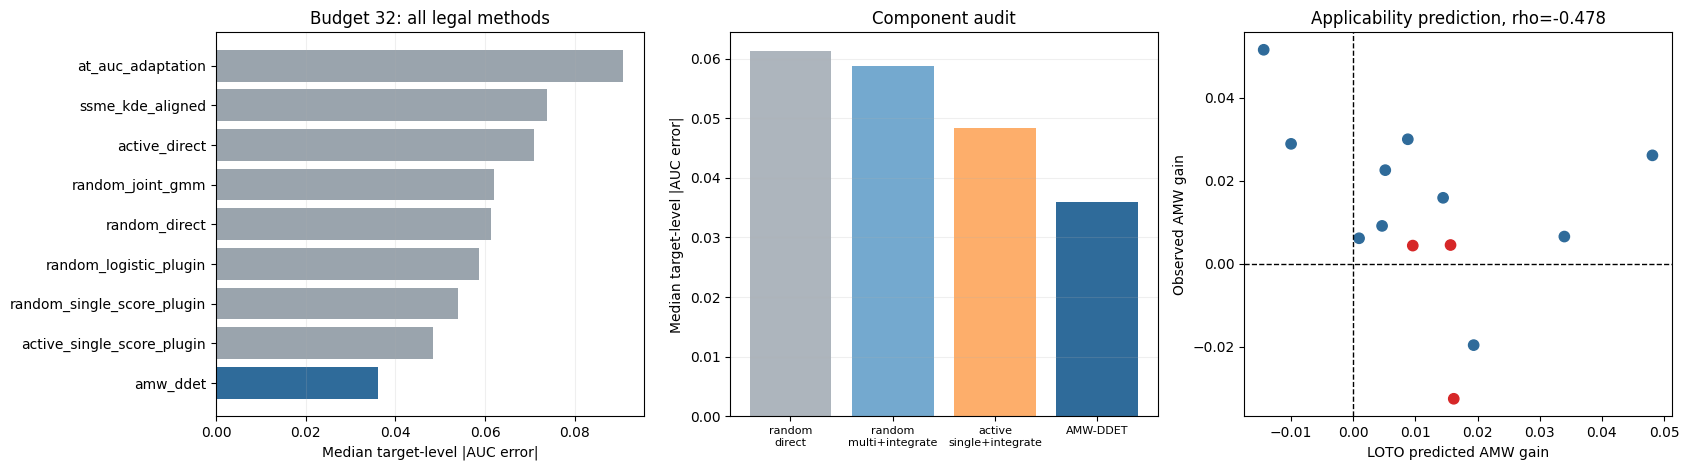

,method,median,mean,max
1,active_no_crossfit_plugin,0.033547,0.046552,0.112315
3,amw_ddet,0.036025,0.046853,0.107008
2,active_single_score_plugin,0.048406,0.055256,0.116972
8,random_single_score_plugin,0.053931,0.055112,0.085606
7,random_logistic_plugin,0.058710,0.051035,0.073913
5,random_direct,0.061348,0.058625,0.092033
6,random_joint_gmm,0.061972,0.072775,0.131658
0,active_direct,0.070929,0.073743,0.139335
9,ssme_kde_aligned,0.073713,0.087820,0.160389
4,at_auc_adaptation,0.090820,0.088377,0.138623


,competitor,targets,mean_error_reduction,median_error_reduction,exact_one_sided_signflip_p
0,random_direct,13,0.011772,0.009079,0.036499
1,random_logistic_plugin,13,0.004182,0.003720,0.255493
2,random_joint_gmm,13,0.025922,0.017792,0.006592
3,at_auc_adaptation,13,0.041524,0.038518,0.000122
4,ssme_kde_aligned,13,0.040967,0.043329,0.002075


,target,modality,replicate,evidence_dimension,numerical_rank,effective_rank,effective_rank_ratio,max_abs_score_correlation,covariance_min_eigenvalue,covariance_condition_number,active_minus_random_logdet,support_nearest_distance_q95,witness_prevalence,witness_classes,witness_units,amw_minus_random_error,amw_gain,loto_predicted_amw_gain,hard_applicability_failure
0,APTOS_2019,retinal_fundus,49.5,2.0,2.0,1.922766,0.961383,0.385360,0.615225,2.253938,2.135539,1.321322,0.593750,2.0,32.0,-0.015847,0.015847,0.014455,False
1,BUSI_WHU_2025_V3,breast_ultrasound,49.5,2.0,2.0,1.990461,0.995231,0.137497,0.915193,1.319627,1.949092,1.069005,0.406250,2.0,32.0,0.019647,-0.019647,0.019373,False
2,BUS_BRA_2024,breast_ultrasound,49.5,2.0,2.0,1.996978,0.998489,0.035341,0.622755,1.168457,2.161613,1.146300,0.321429,2.0,55.0,-0.051515,0.051515,-0.014424,False
3,DeepDRiD,retinal_fundus,49.5,2.0,2.0,1.895212,0.947606,0.444906,0.464634,2.607764,1.399832,0.966246,0.500000,2.0,64.0,-0.022512,0.022512,0.005146,False
4,EyePACS_2015,retinal_fundus,49.5,3.0,3.0,2.791923,0.930641,0.423072,0.418029,3.058897,2.644932,1.970211,0.515625,2.0,64.0,-0.026078,0.026078,0.048147,False
5,HAM10000,dermoscopy,50.5,2.0,2.0,1.950892,0.975446,0.309523,0.691962,1.896549,2.986629,1.308493,0.250000,2.0,32.0,-0.004473,0.004473,0.015651,False
6,IDRiD,retinal_fundus,49.5,2.0,2.0,1.775250,0.887625,0.631655,0.371992,4.429691,1.306418,0.904174,0.593750,2.0,32.0,-0.006512,0.006512,0.033970,False
7,ISIC_MSK1,dermoscopy,49.5,2.0,2.0,1.948590,0.974295,0.312126,0.649466,1.926142,2.096242,1.027280,0.235294,2.0,35.0,-0.004334,0.004334,0.009573,False
8,ISIC_UDA1,dermoscopy,49.5,2.0,2.0,1.978140,0.989070,0.207949,0.797790,1.525090,2.373460,0.948713,0.343750,2.0,32.0,0.032575,-0.032575,0.016168,False
9,Montgomery_CXR,chest_radiography,49.5,2.0,2.0,1.956076,0.978038,0.293120,0.719732,1.829336,0.873198,0.623512,0.468750,2.0,32.0,-0.006101,0.006101,0.000929,False


method,target,active_direct,active_no_crossfit_plugin,active_single_score_plugin,amw_ddet,at_auc_adaptation,random_direct,random_joint_gmm,random_logistic_plugin,random_single_score_plugin,ssme_kde_aligned
0,HAM10000,0.072588,0.086791,0.091653,0.087560,0.118070,0.092033,0.093603,0.073913,0.083182,0.109419
1,ISIC_MSK1,0.139335,0.058794,0.052793,0.057014,0.105641,0.061348,0.101700,0.058994,0.065185,0.119197
2,ISIC_UDA1,0.080230,0.112315,0.116972,0.107008,0.116246,0.074433,0.094822,0.064463,0.074443,0.073713


,target,modality,access_status,outcome_resolved
0,BUSI_CAIRO_2019,breast_ultrasound,acquisition_preflight_required,False
1,OASBUD_2017,breast_ultrasound,official_public_asset_preflight_possible,False
2,DERM7PT_2019,dermoscopy,official_credentials_required,False


,gate,observed,threshold,passed
0,G1_immutable_parents,T2-D final + 2 result files + 4 prediction tab...,all exact,True
1,G2_parent_reproduction,11/11; AMW=0.036025007561; random=0.061348261667,exact parent metrics,True
2,G3_strong_baseline_coverage,SSME 13/13; AT 13/13,13/13 each,True
3,G4_amw_vs_best_strong,AMW 0.036025; best random_logistic_plugin 0.05...,AMW <= best + 0.01,True
4,G5_frozen_random_direct_gain,0.412779,>=0.25,True
5,G6_multisource_ablation,AMW 0.036025; active single 0.048406,AMW <= active single + 0.01,True
6,G7_crossfit_audit,True,True; no-crossfit never replaces primary,True
7,G8_applicability_and_dermoscopy,13 targets; dermoscopy table rows=3; LOTO rho=...,"complete, no favorable result required",True
8,G9_frozen_certificate,0.1656,0.16559988 unchanged,True
9,G10_blind_feasibility_ledger,3 targets / 2 modalities / min p=0.125,ledger explicit; min p=0.125 acknowledged,True



===== STAGE T2-E COMPLETE =====
# Stage T2-E paper-upgrade audit

- Decision: `AUTHORISE_FROZEN_BLIND_PREREGISTRATION_AND_ASSET_ACQUISITION_PREFLIGHT_ONLY`
- Frozen gates: `11 / 11`
- Frozen AMW-DDET target-level median MAE: `0.036025`
- Best strong baseline: `random_logistic_plugin` with target-level median MAE `0.058710`
- Active single-score ablation MAE: `0.048406`
- Applicability LOTO Spearman: `-0.478022`
- Current locked blind: `3` targets / `2` modalities / minimum one-sided exact p `0.125`
- Frozen blind conformal radius: `0.16559988`

- SSME result is official-algorithm-aligned self-contained reimplementation, not an author-run binary result.
- AT result is a preregistered AUC adaptation of Active Testing principles, not a claimed official drop-in AUC implementation.
- Stage 12 authorised: `False`
- Locked blind assets touched: `False`

Passing authorises only blind preregistration freeze and asset-access preflight. It does not authorise blind outcome execution.

Final recor

In [5]:
# @title T2-E-4. Target-level inference, component audit, dermoscopy analysis, blind ledger, and frozen gates
parent_primary=parent_results[parent_results.budget==BUDGET].copy()
combined=pd.concat([parent_primary,new_results],ignore_index=True,sort=False)
target_error=combined.groupby(['method','target','modality'],as_index=False).absolute_error.median()
method_summary=target_error.groupby('method').absolute_error.agg(['median','mean','max']).reset_index().sort_values('median')
edge_summary=combined.groupby(['method','source','target','modality'],as_index=False).agg(
    estimate_auc=('estimate_auc','median'),true_auc=('true_auc','first'),absolute_error=('absolute_error','median'))
rank_summary=edge_summary.groupby('method').apply(
    lambda frame: pd.Series({'edges':len(frame),'spearman':spearmanr(frame.estimate_auc,frame.true_auc).statistic,'median_edge_mae':frame.absolute_error.median()}),
    include_groups=False).reset_index()

target_wide=target_error.pivot(index='target',columns='method',values='absolute_error')
amw_mae=float(target_wide.amw_ddet.median()); direct_mae=float(target_wide.random_direct.median())
relative_improvement=float(1-amw_mae/direct_mae)
strong=['random_direct','random_logistic_plugin','random_joint_gmm','at_auc_adaptation','ssme_kde_aligned']
strong_summary=method_summary[method_summary.method.isin(strong)].copy()
best_strong=float(strong_summary['median'].min()); best_strong_method=str(strong_summary.loc[strong_summary['median'].idxmin(),'method'])
single_mae=float(target_wide.active_single_score_plugin.median())

def exact_signflip(differences):
    values=pd.Series(differences).dropna().to_numpy(float); observed=values.mean(); null=[]
    for mask in range(1<<len(values)):
        signs=np.asarray([1 if (mask>>i)&1 else -1 for i in range(len(values))])
        null.append(np.mean(values*signs))
    return float(np.mean(np.asarray(null)>=observed))
pairwise=[]
for competitor in strong:
    if competitor=='random_direct': pass
    difference=target_wide[competitor]-target_wide.amw_ddet
    pairwise.append({'competitor':competitor,'targets':difference.notna().sum(),'mean_error_reduction':difference.mean(),'median_error_reduction':difference.median(),'exact_one_sided_signflip_p':exact_signflip(difference)})
pairwise=pd.DataFrame(pairwise)

diagnostic_target=diagnostics.groupby(['target','modality'],as_index=False).median(numeric_only=True)
diagnostic_target['amw_minus_random_error']=diagnostic_target.target.map((target_wide.amw_ddet-target_wide.random_direct).to_dict())
diagnostic_target['amw_gain']=diagnostic_target.target.map((target_wide.random_direct-target_wide.amw_ddet).to_dict())
feature_columns=['effective_rank_ratio','max_abs_score_correlation','covariance_condition_number','active_minus_random_logdet','support_nearest_distance_q95']
xdiag=diagnostic_target[feature_columns].replace([np.inf,-np.inf],np.nan).fillna(diagnostic_target[feature_columns].median()).to_numpy(float)
ydiag=diagnostic_target.amw_gain.to_numpy(float); predicted=np.zeros(len(ydiag))
loo=LeaveOneOut()
for train,test in loo.split(xdiag):
    model=make_pipeline(StandardScaler(),Ridge(alpha=1.0)).fit(xdiag[train],ydiag[train])
    predicted[test]=model.predict(xdiag[test])
diagnostic_target['loto_predicted_amw_gain']=predicted
applicability_rho=float(spearmanr(predicted,ydiag).statistic)
diagnostic_target['hard_applicability_failure']=(
    (diagnostic_target.numerical_rank<np.minimum(2,diagnostic_target.evidence_dimension))|(diagnostic_target.max_abs_score_correlation>0.995)|
    (diagnostic_target.covariance_condition_number>1e8)|(diagnostic_target.witness_prevalence<0.05)|
    (diagnostic_target.witness_prevalence>0.95)|(diagnostic_target.witness_classes<2))
dermoscopy=target_error[target_error.modality=='dermoscopy'].pivot(index='target',columns='method',values='absolute_error').reset_index()

observed_radius=float(parent_certificates.conformal_radius.max())
assert abs(observed_radius-BLIND_CONFORMAL_RADIUS)<5e-9
blind_ledger=pd.DataFrame([
    {'target':'BUSI_CAIRO_2019','modality':'breast_ultrasound','access_status':'acquisition_preflight_required','outcome_resolved':False},
    {'target':'OASBUD_2017','modality':'breast_ultrasound','access_status':'official_public_asset_preflight_possible','outcome_resolved':False},
    {'target':'DERM7PT_2019','modality':'dermoscopy','access_status':'official_credentials_required','outcome_resolved':False},
])
blind_target_count=len(blind_ledger); blind_modalities=blind_ledger.modality.nunique(); minimum_exact_p=1/(2**blind_target_count)

ssme_coverage=new_results[new_results.method=='ssme_kde_aligned'].target.nunique()
at_coverage=new_results[new_results.method=='at_auc_adaptation'].target.nunique()
crossfit_audit_complete=new_results[new_results.method=='active_no_crossfit_plugin'].target.nunique()==13
gates=pd.DataFrame([
    {'gate':'G1_immutable_parents','observed':'T2-D final + 2 result files + 4 prediction tables + 30-edge library verified','threshold':'all exact','passed':True},
    {'gate':'G2_parent_reproduction','observed':f'11/11; AMW={amw_mae:.12f}; random={direct_mae:.12f}','threshold':'exact parent metrics','passed':abs(amw_mae-parent['metrics']['amw_ddet_target_level_median_mae'])<1e-12 and abs(direct_mae-parent['metrics']['random_direct_target_level_median_mae'])<1e-12},
    {'gate':'G3_strong_baseline_coverage','observed':f'SSME {ssme_coverage}/13; AT {at_coverage}/13','threshold':'13/13 each','passed':ssme_coverage==13 and at_coverage==13},
    {'gate':'G4_amw_vs_best_strong','observed':f'AMW {amw_mae:.6f}; best {best_strong_method} {best_strong:.6f}','threshold':'AMW <= best + 0.01','passed':amw_mae<=best_strong+0.01},
    {'gate':'G5_frozen_random_direct_gain','observed':relative_improvement,'threshold':'>=0.25','passed':relative_improvement>=0.25},
    {'gate':'G6_multisource_ablation','observed':f'AMW {amw_mae:.6f}; active single {single_mae:.6f}','threshold':'AMW <= active single + 0.01','passed':amw_mae<=single_mae+0.01},
    {'gate':'G7_crossfit_audit','observed':crossfit_audit_complete,'threshold':'True; no-crossfit never replaces primary','passed':crossfit_audit_complete},
    {'gate':'G8_applicability_and_dermoscopy','observed':f'13 targets; dermoscopy table rows={len(dermoscopy)}; LOTO rho={applicability_rho:.3f}','threshold':'complete, no favorable result required','passed':len(diagnostic_target)==13 and len(dermoscopy)>=1},
    {'gate':'G9_frozen_certificate','observed':observed_radius,'threshold':'0.16559988 unchanged','passed':abs(observed_radius-BLIND_CONFORMAL_RADIUS)<5e-9},
    {'gate':'G10_blind_feasibility_ledger','observed':f'{blind_target_count} targets / {blind_modalities} modalities / min p={minimum_exact_p:.3f}','threshold':'ledger explicit; min p=0.125 acknowledged','passed':blind_target_count==3 and blind_modalities==2 and abs(minimum_exact_p-.125)<1e-12},
    {'gate':'G11_blind_untouched','observed':not blind_ledger.outcome_resolved.any(),'threshold':'True; Stage 12 false','passed':not blind_ledger.outcome_resolved.any()},
])
gates['passed']=gates.passed.astype(bool); gate_count=int(gates.passed.sum())
decision='AUTHORISE_FROZEN_BLIND_PREREGISTRATION_AND_ASSET_ACQUISITION_PREFLIGHT_ONLY' if gate_count==len(gates) else 'DO_NOT_AUTHORISE_BLIND_EXECUTION_RESOLVE_PUBLICATION_GAPS'

write_csv_once(P1/'StageT2-E_All_Method_Target_Level_Summary_v0.1.csv',method_summary)
write_csv_once(P1/'StageT2-E_Strong_Baseline_Paired_Target_Inference_v0.1.csv',pairwise)
write_csv_once(P1/'StageT2-E_Edge_Rank_Summary_v0.1.csv',rank_summary)
write_csv_once(P2/'StageT2-E_Applicability_Target_Summary_And_LOTO_v0.1.csv',diagnostic_target)
write_csv_once(P2/'StageT2-E_Dermoscopy_Predeclared_Failure_Audit_v0.1.csv',dermoscopy)
write_csv_once(P3/'StageT2-E_Blind_Feasibility_Ledger_v0.1.csv',blind_ledger)
write_csv_once(P3/'StageT2-E_Frozen_Gates_v0.1.csv',gates)

fig,axes=plt.subplots(1,3,figsize=(17,4.8))
plot_summary=method_summary[method_summary.method!='active_no_crossfit_plugin'].sort_values('median')
axes[0].barh(plot_summary.method,plot_summary['median'],color=['#2f6b9a' if x=='amw_ddet' else '#9aa4ad' for x in plot_summary.method])
axes[0].set_xlabel('Median target-level |AUC error|'); axes[0].set_title('Budget 32: all legal methods'); axes[0].grid(axis='x',alpha=.2)
components=['random_direct','random_logistic_plugin','active_single_score_plugin','amw_ddet']
comp=method_summary.set_index('method').loc[components,'median']
axes[1].bar(np.arange(len(comp)),comp,color=['#adb5bd','#74a9cf','#fdae6b','#2f6b9a'])
axes[1].set_xticks(np.arange(len(comp)),['random\ndirect','random\nmulti+integrate','active\nsingle+integrate','AMW-DDET'],fontsize=8)
axes[1].set_ylabel('Median target-level |AUC error|'); axes[1].set_title('Component audit'); axes[1].grid(axis='y',alpha=.2)
colors=['#d62728' if x=='dermoscopy' else '#2f6b9a' for x in diagnostic_target.modality]
axes[2].scatter(diagnostic_target.loto_predicted_amw_gain,diagnostic_target.amw_gain,c=colors,s=55)
axes[2].axhline(0,color='k',lw=1,ls='--'); axes[2].axvline(0,color='k',lw=1,ls='--')
axes[2].set_xlabel('LOTO predicted AMW gain'); axes[2].set_ylabel('Observed AMW gain'); axes[2].set_title(f'Applicability prediction, rho={applicability_rho:.3f}')
fig.tight_layout(); figure_path=P4/'StageT2-E_Paper_Upgrade_Main_Figure_v0.1.png'
if not figure_path.exists(): fig.savefig(figure_path,dpi=180,bbox_inches='tight')
plt.show()

metrics={
    'primary_budget':BUDGET,'eligible_targets':13,'eligible_edges':27,'modalities':4,
    'parent_amw_target_median_mae':amw_mae,'parent_random_direct_target_median_mae':direct_mae,
    'parent_relative_improvement':relative_improvement,'best_strong_baseline':best_strong_method,
    'best_strong_baseline_target_median_mae':best_strong,'active_single_score_target_median_mae':single_mae,
    'applicability_loto_spearman':applicability_rho,'hard_applicability_failures':int(diagnostic_target.hard_applicability_failure.sum()),
    'blind_locked_targets':blind_target_count,'blind_locked_modalities':blind_modalities,
    'blind_minimum_one_sided_exact_p':minimum_exact_p,'frozen_blind_conformal_radius':observed_radius,
}
final_payload={
    'stage':'StageT2-E','analysis':'development_only_paper_upgrade_audit','protocol_seal_sha256':protocol['seal_sha256'],
    'parent_final_sha256':PARENT_FINAL_SHA,'metrics':metrics,'frozen_gates_passed':gate_count,
    'frozen_gates_total':len(gates),'decision':decision,'lightweight_replicates_expected':100,
    'lightweight_replicates_executed':N_LIGHT,'ssme_replicates_expected':30,'ssme_replicates_executed':N_SSME,
    'local_fast_mode':LOCAL_MODE,'stage12_authorised':False,'locked_blind_assets_touched':False,
    'result_sha256':{
        'new_replicates':sha_file(P1/'StageT2-E_New_Baseline_And_Ablation_Replicates_v0.1.csv'),
        'applicability':sha_file(P2/'StageT2-E_Applicability_Target_Summary_And_LOTO_v0.1.csv'),
        'blind_ledger':sha_file(P3/'StageT2-E_Blind_Feasibility_Ledger_v0.1.csv'),
        'gates':sha_file(P3/'StageT2-E_Frozen_Gates_v0.1.csv'),
    },
}
final=seal(P4/'StageT2-E_Complete_v0.1.json',final_payload,'final_record_sha256','completed_utc')
summary='\n'.join([
    '# Stage T2-E paper-upgrade audit','',f'- Decision: `{decision}`',f'- Frozen gates: `{gate_count} / {len(gates)}`',
    f'- Frozen AMW-DDET target-level median MAE: `{amw_mae:.6f}`',
    f'- Best strong baseline: `{best_strong_method}` with target-level median MAE `{best_strong:.6f}`',
    f'- Active single-score ablation MAE: `{single_mae:.6f}`',
    f'- Applicability LOTO Spearman: `{applicability_rho:.6f}`',
    f'- Current locked blind: `{blind_target_count}` targets / `{blind_modalities}` modalities / minimum one-sided exact p `{minimum_exact_p:.3f}`',
    f'- Frozen blind conformal radius: `{observed_radius:.8f}`','',
    '- SSME result is official-algorithm-aligned self-contained reimplementation, not an author-run binary result.',
    '- AT result is a preregistered AUC adaptation of Active Testing principles, not a claimed official drop-in AUC implementation.',
    '- Stage 12 authorised: `False`','- Locked blind assets touched: `False`','',
    'Passing authorises only blind preregistration freeze and asset-access preflight. It does not authorise blind outcome execution.',
])+'\n'
write_text_once(P4/'StageT2-E_Result_Summary_v0.1.md',summary)
display(method_summary); display(pairwise); display(diagnostic_target); display(dermoscopy); display(blind_ledger); display(gates)
print('\n===== STAGE T2-E COMPLETE =====')
print(summary)
print('Final record SHA256:',final['final_record_sha256'])


## 解释边界

- 通过 11/11 不等于 blind validation 通过，只表示投稿前 development 压力测试完整且允许封存预注册。
- `ssme_kde_aligned` 复现公开算法结构；正式投稿应再做作者代码环境兼容核验，并透明报告任何差异。
- `at_auc_adaptation` 是 pairwise AUC 的预声明适配。若审稿需要作者原框架的另一种 importance-surrogate，应作为补充敏感性分析，而不能改写当前结果。
- 适用性 LOTO 若不能预测 dermoscopy 失败，这是重要负结果；不得在同一批 13 个 targets 上调阈值后声称成功。
- 当前 3 个 locked blind targets 无法单独达到目标簇 `p<=0.05`。扩充 cohort 必须在 outcome 解析前完成数据版本、源模型、标签映射、独立组和哈希承诺。
